<a href="https://colab.research.google.com/github/meevalvec2529-cloud/24BSE1211-PDE-MicroProject-Group-4-/blob/main/Microproject_Group_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1D Image Blurring and Restoration Using the Heat Equation**


#Phase 2: Computational Micro-Project


##**Abstract**

This computational micro-project implements the one-dimensional heat equation
$$\frac{\partial I}{\partial t}=\alpha\frac{\partial^2 I}{\partial x^2}$$
to study image blurring as a diffusion process. A sharp step edge is used as the initial image signal. The
analytical Fourier sine-series solution is evaluated numerically using NumPy, and the results are visualized using
Matplotlib.
The simulation demonstrates that high-frequency Fourier modes decay faster than low-frequency modes
according to
$$D_n(t)=\exp\left[-\alpha\left(\frac{n\pi}{L}\right)^2t\right].$$

Consequently, high-frequency components associated with sharp edges and fine details disappear more rapidly than low-frequency components, causing the initially sharp image signal to become progressively smoother and blurred. The project also examines the influence of the diffusion coefficient and diffusion time on the amount of blurring.The notebook also illustrates the difficulty of direct image
restoration because reversing the diffusion process amplifies high-frequency noise.Therefore, practical image restoration requires controlled or regularized techniques rather than direct inversion.


#**1.Mathematical Model**
Consider a one-dimensional image intensity  $(I(x,t)) on (0<x<L)$.
Governing equation:
$$I_t=\alpha I_{xx},\alpha>0.$$
Boundary conditions:

$$I(0,t)=0,\qquad I(L,t)=0$$
Initial condition: sharp step edge
$I(x,0)=I_0H(x-a)$
where \(a\) is the edge position.
Using separation of variables and Fourier sine series,
$$I(x,t)=\sum_{n=1}^{\infty}B_n
\sin\left(\frac{n\pi x}{L}\right)
\exp\left[-\alpha\left(\frac{n\pi}{L}\right)^2t\right].$$
For the step input,
$$B_n=\frac{2I_0}{n\pi}
\left[
\cos\left(\frac{n\pi a}{L}\right)-(-1)^n
\right].$$
The exponential term is responsible for frequency-dependent decay and image blur.


In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
# Improve plot appearance
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11


#**2. Define the Physical and Computational Parameters**
The values below can be changed to study different amounts of blur

In [ ]:
# Physical parameters
L = 1.0 # Length of the 1D image domain
I0 = 1.0 # Intensity level
a = L / 2 # Position of the sharp edge
alpha = 0.02 # Diffusion / blurring coefficient
# Computational parameters
Nx = 1000 # Number of spatial points
N_modes = 200 # Number of Fourier modes
x = np.linspace(0, L, Nx)
print(f"Domain length L = {L}")
print(f"Edge position a = {a}")
print(f"Diffusion coefficient alpha = {alpha}")
print(f"Fourier modes used = {N_modes}")


Domain length L = 1.0
Edge position a = 0.5
Diffusion coefficient alpha = 0.02
Fourier modes used = 200


#**3. Initial Sharp Edge**
The step function represents a sudden change in image intensity. The boundary values are kept at zero to match
the mathematical boundary conditions.

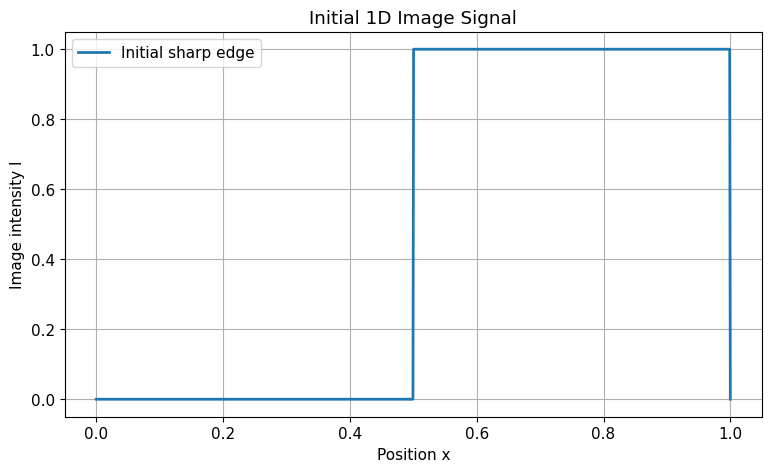

In [ ]:
def initial_step(x, a, I0):
 """Return the initial step-edge intensity profile."""
 return np.where((x >= a) & (x < L), I0, 0.0)
I_initial = initial_step(x, a, I0)
plt.plot(x, I_initial, linewidth=2, label="Initial sharp edge")
plt.xlabel("Position x")
plt.ylabel("Image intensity I")
plt.title("Initial 1D Image Signal")
plt.grid(True)
plt.legend()
plt.show()

#**4. Fourier Coefficients and Heat-Equation Solution**
The following functions implement the Fourier coefficient \(B_n\) and the truncated Fourier-series solution.


In [ ]:
def fourier_coefficients(L, a, I0, N):
 """Compute Fourier sine coefficients B_n for the step edge."""
 n = np.arange(1, N + 1)
 Bn = (2 * I0 / (n * np.pi)) * (
 np.cos(n * np.pi * a / L) - (-1)**n
 )
 return n, Bn
def heat_solution(x, t, L, a, I0, alpha, N):
 """Evaluate the truncated Fourier-series solution of the heat equation."""
 n, Bn = fourier_coefficients(L, a, I0, N)
 spatial_modes = np.sin(np.outer(n * np.pi / L, x))
 decay = np.exp(-alpha * (n * np.pi / L)**2 * t)
 return np.sum((Bn * decay)[:, None] * spatial_modes, axis=0)
# Check the Fourier coefficients
n, Bn = fourier_coefficients(L, a, I0, N_modes)
print("First 10 Fourier coefficients:")
for i in range(10):
 print(f"n = {n[i]:2d}, B_n = {Bn[i]: .6f}")

First 10 Fourier coefficients:
n =  1, B_n =  0.636620
n =  2, B_n = -0.636620
n =  3, B_n =  0.212207
n =  4, B_n =  0.000000
n =  5, B_n =  0.127324
n =  6, B_n = -0.212207
n =  7, B_n =  0.090946
n =  8, B_n =  0.000000
n =  9, B_n =  0.070736
n = 10, B_n = -0.127324


#**5. Numerical Simulation of Image Blurring**
The profiles below show how the initially sharp edge changes as diffusion time increases.


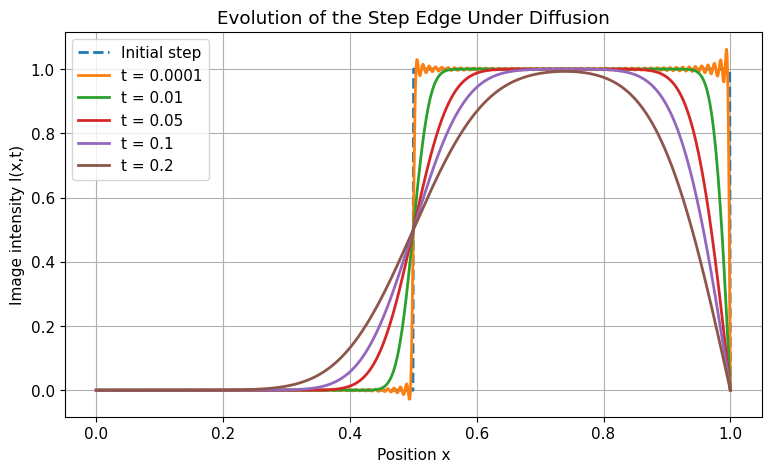

In [ ]:
times = [0.0001, 0.01, 0.05, 0.10, 0.20]
plt.plot(x, I_initial, "--", linewidth=2, label="Initial step")
for t in times:
 I_t = heat_solution(x, t, L, a, I0, alpha, N_modes)
 plt.plot(x, I_t, linewidth=2, label=f"t = {t}")
plt.xlabel("Position x")
plt.ylabel("Image intensity I(x,t)")
plt.title("Evolution of the Step Edge Under Diffusion")
plt.grid(True)
plt.legend()
plt.show()

#**Observation**

As time increases, the sudden transition near the edge becomes smoother. This is the computational
representation of image blurring.


#**6. Visual Comparison: Sharp Signal vs Blurred Signal**

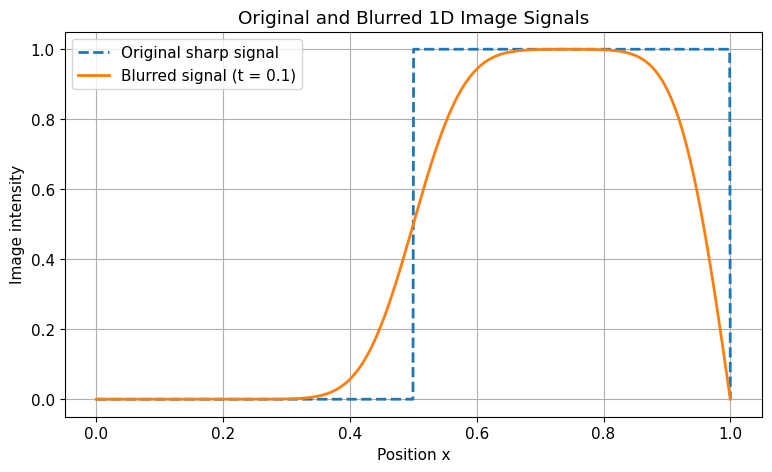

In [ ]:
t_blur = 0.10
I_blurred = heat_solution(x, t_blur, L, a, I0, alpha, N_modes)
plt.plot(x, I_initial, "--", linewidth=2, label="Original sharp signal")
plt.plot(x, I_blurred, linewidth=2, label=f"Blurred signal (t = {t_blur})")
plt.xlabel("Position x")
plt.ylabel("Image intensity")
plt.title("Original and Blurred 1D Image Signals")
plt.grid(True)
plt.legend()
plt.show()

#**7. Frequency-Dependent Decay**
For the $(n)$-th Fourier mode,
$D_n(t)=\exp\left[-\alpha\left(\frac{n\pi}{L}\right)^2t\right].$
Because the exponent contains $n^2$, high-frequency modes decay much faster.

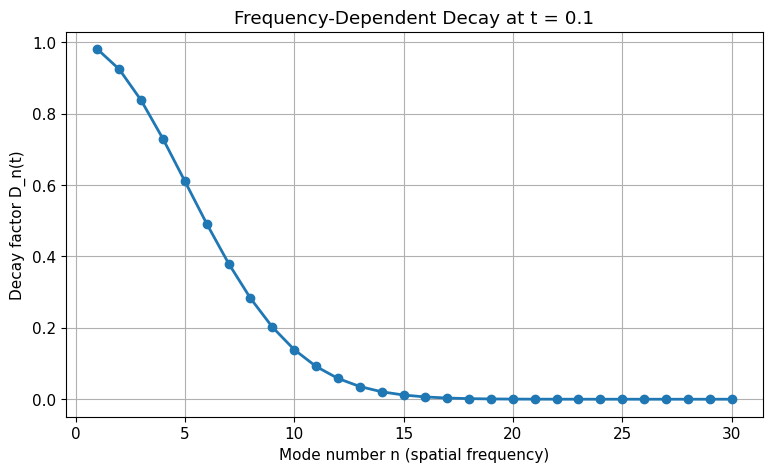

In [ ]:
n_plot = np.arange(1, 31)
t_decay = 0.10
D = np.exp(-alpha * (n_plot * np.pi / L)**2 * t_decay)
plt.plot(n_plot, D, "o-", linewidth=2)
plt.xlabel("Mode number n (spatial frequency)")
plt.ylabel("Decay factor D_n(t)")
plt.title(f"Frequency-Dependent Decay at t = {t_decay}")

plt.grid(True)
plt.show()

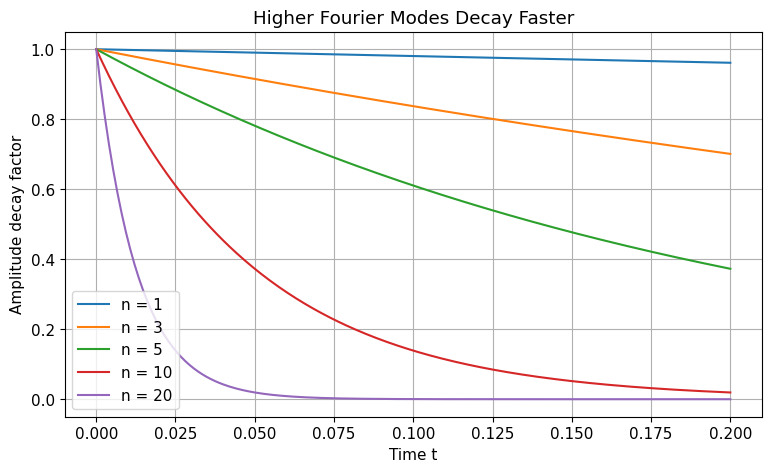

In [ ]:
#Compare selected low- and high-frequency modes over time
t_values = np.linspace(0, 0.20, 300)
selected_modes = [1, 3, 5, 10, 20]
for mode in selected_modes:
 D_mode = np.exp(-alpha * (mode * np.pi / L)**2 * t_values)
 plt.plot(t_values, D_mode, label=f"n = {mode}")
plt.xlabel("Time t")
plt.ylabel("Amplitude decay factor")
plt.title("Higher Fourier Modes Decay Faster")
plt.grid(True)
plt.legend()
plt.show()

#**8. Effect of the Diffusion Coefficient α**
A larger value of $alpha$ produces faster diffusion and therefore stronger blurring.

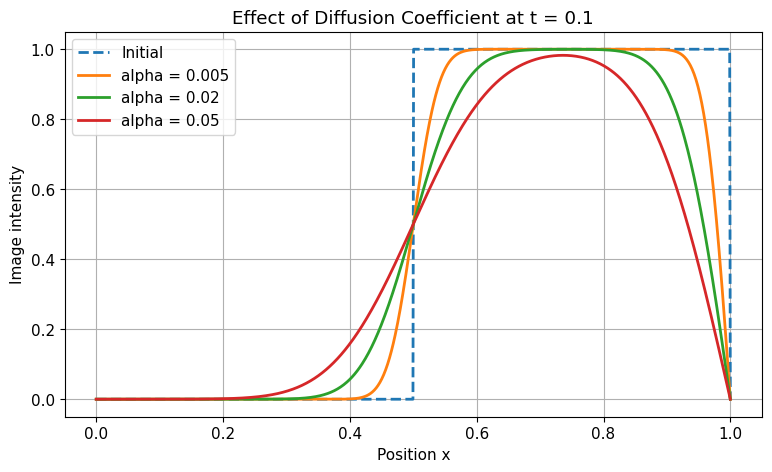

In [ ]:
alphas = [0.005, 0.02, 0.05]
t_compare = 0.10
plt.plot(x, I_initial, "--", linewidth=2, label="Initial")
for alpha_test in alphas:
 I_test = heat_solution(x, t_compare, L, a, I0, alpha_test, N_modes)
 plt.plot(x, I_test, linewidth=2, label=f"alpha = {alpha_test}")
plt.xlabel("Position x")
plt.ylabel("Image intensity")
plt.title(f"Effect of Diffusion Coefficient at t = {t_compare}")
plt.grid(True)
plt.legend()
plt.show()

#**9. Computational Illustration of Image Restoration**
The blurred Fourier coefficient is
$$B_n^{obs}=B_n
\exp\left[-\alpha\left(\frac{n\pi}{L}\right)^2t\right].$$
The theoretical inverse operation multiplies by
$$\exp\left[+\alpha\left(\frac{n\pi}{L}\right)^2t\right].$$
This can amplify even very small amounts of noise. The following experiment demonstrates this instability.

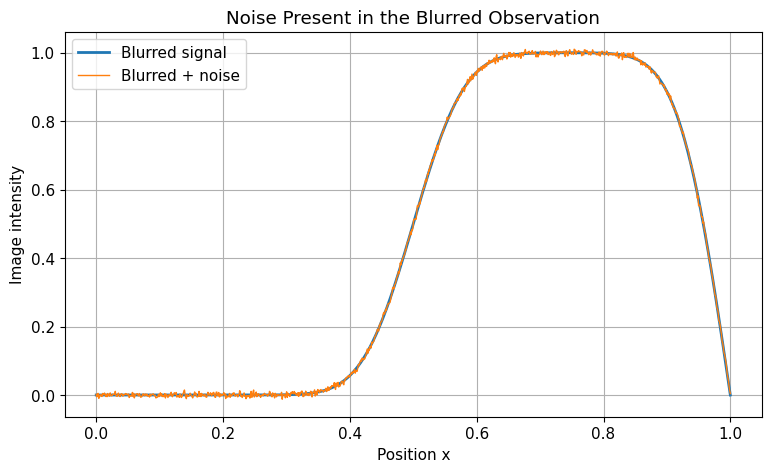

In [ ]:
# Create a synthetic noisy blurred signal
rng = np.random.default_rng(42)
noise_level = 0.005
noisy_blurred = I_blurred + noise_level * rng.normal(size=x.size)
plt.plot(x, I_blurred, linewidth=2, label="Blurred signal")
plt.plot(x, noisy_blurred, linewidth=1, label="Blurred + noise")
plt.xlabel("Position x")
plt.ylabel("Image intensity")
plt.title("Noise Present in the Blurred Observation")
plt.grid(True)
plt.legend()
plt.show()

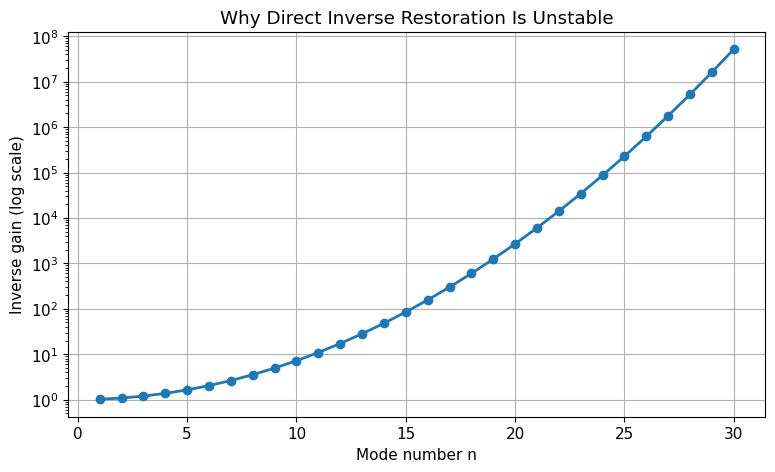

The inverse gain grows rapidly for high-frequency modes.
Therefore, noise in high-frequency components can be strongly amplified.


In [ ]:
# Demonstrate amplification of high-frequency components during inverse diffusion
n_restore = np.arange(1, 31)
inverse_gain = np.exp(alpha * (n_restore * np.pi / L)**2 * t_blur)
plt.semilogy(n_restore, inverse_gain, "o-", linewidth=2)
plt.xlabel("Mode number n")
plt.ylabel("Inverse gain (log scale)")
plt.title("Why Direct Inverse Restoration Is Unstable")
plt.grid(True)
plt.show()
print("The inverse gain grows rapidly for high-frequency modes.")
print("Therefore, noise in high-frequency components can be strongly amplified.")


#**10. Verification of Boundary Conditions**
The Fourier sine-series solution should satisfy
I(0,t)=I(L,t)=0.


In [ ]:
test_time = 0.10
I_test = heat_solution(x, test_time, L, a, I0, alpha, N_modes)
print(f"I(0, {test_time}) ≈ {I_test[0]:.3e}")
print(f"I(L, {test_time}) ≈ {I_test[-1]:.3e}")

I(0, 0.1) ≈ 0.000e+00
I(L, 0.1) ≈ 5.059e-16


#**11. Results and Physical Interpretation**
Main computational results
1. The initial step edge contains many spatial frequency components.
2. Diffusion multiplies each Fourier mode by an exponential decay factor.
3. The decay rate is proportional to \(n^2\).
4. High-frequency modes disappear faster than low-frequency modes.
5. Loss of high-frequency information smooths sharp edges and produces blur.
6. Increasing either diffusion time \(t\) or coefficient \(■lpha\) increases the amount of blurring.
7. Direct inverse restoration is unstable because high-frequency noise can be exponentially amplified.

The computational plots therefore agree with the mathematical theory developed in Phase 1.
#**12. Final Engineering Conclusion**
This micro-project successfully models 1D image blurring as a diffusion process using the heat equation. The
NumPy implementation evaluates the Fourier sine-series solution, while Matplotlib visualizations clearly show
the progressive smoothing of a sharp edge.
The key engineering insight is that diffusion behaves like a low-pass filter: low spatial frequencies are retained
relatively well, whereas high spatial frequencies associated with edges and fine details decay rapidly. This
explains why images become blurred.
The restoration experiment also shows an important limitation: simply reversing the diffusion process is
mathematically unstable because noise can be strongly amplified. Practical image restoration therefore requires
controlled or regularized methods.
Hence, the computational results validate the theoretical conclusions obtained in Phase 1.
#**13. References**
1. J. Crank, *The Mathematics of Diffusion*, Oxford University Press.
2. L. C. Evans, *Partial Differential Equations*, American Mathematical Society.
3. R. C. Gonzalez and R. E. Woods, *Digital Image Processing*, Pearson.
4. Group 4, Topic 2 Phase 1 assignment: *1D Image Blurring and Restoration Using the Heat Equation*.